# Real-world OpenML logistic regression

This notebook builds one ordinary Bayesian logistic-regression task from OpenML and runs pretrained AFINs with a standard prior.

We use OpenML `wdbc` (`data_id=1510`), the Wisconsin Diagnostic Breast Cancer dataset: 30 real-valued cell-nucleus features and binary benign/malignant labels.

TabPFN is included as a strong discriminative tabular baseline. This is a natural comparison point because TabPFN is evaluated on OpenML-CC18 and additional OpenML tabular datasets in the original paper: [Hollmann et al., 2023](https://arxiv.org/abs/2207.01848).

Why only one dataset here? This notebook is a walkthrough, not a benchmark. Keeping one OpenML task lets us show the data split, the standard prior, the Bernoulli-logit likelihood, and posterior samples without hiding the Bayesian model behind a loop. Notebook 04 then takes the same template and runs a heavier multi-dataset comparison.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "afin").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import importlib
import afin
import afin.api as _afin_api
import afin.demo as _afin_demo
import afin.spec as _afin_spec

importlib.reload(_afin_spec)
importlib.reload(_afin_api)
importlib.reload(_afin_demo)
afin = importlib.reload(afin)
from afin import BernoulliLogit, GaussianPrior
from afin.demo import (
    classification_result_markdown,
    load_public_afins,
    plot_logistic_coefficients,
    run_afin_logistic_benchmark,
    run_tabpfn_logistic_benchmark,
)

_ = torch.manual_seed(0)


## Download and prepare the OpenML task

This cell is deliberately explicit so it is easy to replace `fetch_openml(...)` with your own `X, y` arrays. The important outputs are `X_train`, `X_test`, `y_train`, and `y_test` for the Bayesian model, plus standardized NumPy arrays for TabPFN.

In [2]:
OPENML_ID = 1510
DATASET_NAME = "wdbc"
TEST_SIZE = 0.30
SEED = 0
ADD_INTERCEPT = True

raw = fetch_openml(data_id=OPENML_ID, as_frame=True, parser="auto")
frame = raw.data.copy()
frame["__target__"] = raw.target
frame = frame.dropna(axis=0)

y_raw = frame.pop("__target__")
X_frame = pd.get_dummies(frame, dummy_na=False, dtype=np.float32)
y_cat = pd.Series(y_raw).astype("category")
labels = list(y_cat.cat.categories)
if len(labels) != 2:
    raise ValueError(f"Expected a binary dataset, got labels={labels}")

y_np = y_cat.cat.codes.to_numpy(dtype=np.int64)
X_np = X_frame.to_numpy(dtype=np.float32)

X_train_raw, X_test_raw, y_train_np, y_test_np = train_test_split(
    X_np,
    y_np,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_np,
)

mean = X_train_raw.mean(axis=0, keepdims=True)
std = np.maximum(X_train_raw.std(axis=0, keepdims=True), 1e-6)
X_train_std = (X_train_raw - mean) / std
X_test_std = (X_test_raw - mean) / std

d_features = int(X_train_std.shape[1])
scale = 2.0 / np.sqrt(max(1, d_features))
X_train_model = scale * X_train_std
X_test_model = scale * X_test_std
feature_names = list(X_frame.columns)
if ADD_INTERCEPT:
    X_train_model = np.concatenate([np.ones((X_train_model.shape[0], 1), dtype=np.float32), X_train_model], axis=1)
    X_test_model = np.concatenate([np.ones((X_test_model.shape[0], 1), dtype=np.float32), X_test_model], axis=1)
    feature_names = ["intercept"] + feature_names

data = {
    "openml_id": OPENML_ID,
    "name": DATASET_NAME,
    "dataset": DATASET_NAME,
    "prior": "standard",
    "regime": "OpenML",
    "labels": labels,
    "positive_label": labels[1],
    "d": int(X_train_model.shape[1]),
    "d_features": d_features,
    "N_train": int(X_train_model.shape[0]),
    "N_test": int(X_test_model.shape[0]),
    "feature_names": feature_names,
    "X_train": torch.tensor(X_train_model, dtype=torch.float32),
    "X_test": torch.tensor(X_test_model, dtype=torch.float32),
    "y_train": torch.tensor(y_train_np, dtype=torch.float32),
    "y_test": torch.tensor(y_test_np, dtype=torch.float32),
    "X_train_tab": X_train_std.astype(np.float32),
    "X_test_tab": X_test_std.astype(np.float32),
    "y_train_tab": y_train_np,
    "y_test_tab": y_test_np,
}
datasets = [data]

summary = pd.DataFrame([{
    "openml_id": data["openml_id"],
    "dataset": data["name"],
    "raw_features": data["d_features"],
    "model_dim": data["d"],
    "N_train": data["N_train"],
    "N_test": data["N_test"],
    "labels": data["labels"],
    "positive_label": data["positive_label"],
}])
display(summary)

,openml_id,dataset,raw_features,model_dim,N_train,N_test,labels,positive_label
0,1510,wdbc,30,31,398,171,"[1, 2]",2


## Build the standard-prior Bayesian model

The first step should be boring on purpose:

$$
z \sim \mathcal{N}(0, I), \qquad y_i \sim \mathrm{BernoulliLogit}(x_i^\top z).
$$

This notebook keeps the prior fixed so the comparison is only about the posterior approximation.

In [3]:
data["prior"] = GaussianPrior(loc=0, scale=1)
data["observed"] = [
    BernoulliLogit(design_matrix=data["X_train"]).observe(data["y_train"]),
]

data["prior"], data["observed"]

(GaussianPrior(loc=0, scale=1),
 [Observed(likelihood=<afin.spec.BernoulliLogit object at 0x74e70feb63c0>, value=tensor([0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0.,
          1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0.,
          0., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0.,
          1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
          1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
          0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
          0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
          1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0.,
          0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
          0., 0., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1.,
          0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,

## AFINs one-shot posterior

We load the two public Hugging Face AFINs checkpoints and run both posterior heads:

- **AFINs Gaussian:** a Gaussian posterior approximation.
- **AFINs Flow:** a flow posterior approximation.

Both methods return posterior samples over the Bayesian coefficient vector `z`.

In [4]:
afin_models = load_public_afins(("gaussian", "flow"))
print("AFINs device:", next(afin_models[0][1].parameters()).device)

results, posterior_cache = run_afin_logistic_benchmark(
    afin_models,
    datasets,
    samples=4_000,
    repeats=3,
    seed=0,
)
display(Markdown(classification_result_markdown(results)))

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

AFINs device: cuda:0


| method | dataset | prior | d | time | train acc | train NLL | test acc | test NLL |
|---|---|---|---:|---:|---:|---:|---:|---:|
| AFINs Gaussian | wdbc | GaussianPrior(loc=0, scale=1) | 31 | 0.216s | 0.698 | 0.561 | 0.632 | 0.640 |
| AFINs Flow | wdbc | GaussianPrior(loc=0, scale=1) | 31 | 0.871s | 0.960 | 0.088 | 0.942 | 0.134 |


## TabPFN baseline

TabPFN returns predictive probabilities directly rather than posterior samples over `z`. The cell first tries the default v2.6 model on CUDA; if the license token is not available, it falls back to the public v2 checkpoint so the notebook remains runnable.

In [5]:
results = [r for r in results if not str(r["method"]).startswith("TabPFN")]
tabpfn_rows, tabpfn_label = run_tabpfn_logistic_benchmark(
    datasets,
    seed=0,
    v26_estimators=8,
    public_v2_estimators=4,
)
results.extend(tabpfn_rows)
display(Markdown(classification_result_markdown(results)))

TabPFN v2.6 skipped: license/API token required.
Falling back to the public TabPFN v2 checkpoint.
TabPFN device: cuda


| method | dataset | prior | d | time | train acc | train NLL | test acc | test NLL |
|---|---|---|---:|---:|---:|---:|---:|---:|
| AFINs Gaussian | wdbc | GaussianPrior(loc=0, scale=1) | 31 | 0.216s | 0.698 | 0.561 | 0.632 | 0.640 |
| AFINs Flow | wdbc | GaussianPrior(loc=0, scale=1) | 31 | 0.871s | 0.960 | 0.088 | 0.942 | 0.134 |
| TabPFN public v2 | wdbc | n/a | 31 | 1.237s | 0.995 | 0.016 | 0.959 | 0.099 |


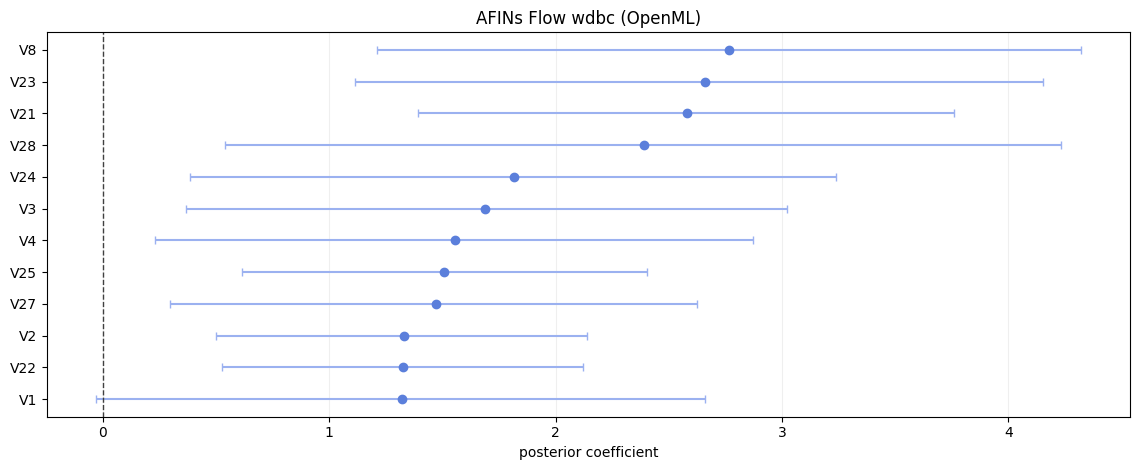

In [6]:
_ = plot_logistic_coefficients(datasets, posterior_cache, method="AFINs Flow")

## Notes

This is the clean baseline: one real OpenML dataset, a standard Normal prior, and a Bernoulli-logit likelihood.

AFINs are not just classifiers here; they produce posterior samples over `z`, so downstream Bayesian tools can inspect uncertainty or reuse the posterior as a proposal. Notebook 04 repeats this same standard-prior model across the binary OpenML comparison list.